In [28]:
import pandas as pd
data = pd.read_csv('processed/all_years_aggregated.csv')


In [32]:
print(data.shape)

(12960, 64)


In [30]:
#count the number of times that weight is 0 
print(data[data['weight'] == 0].shape[0])
# showing where the weight is 0
print(data[data['weight'] == 0])

# overall total rows and columns
print(data.shape)
weight_zero_df = data[data['weight'] == 0]
# distribution of the different groups where the weight is 0


268
       geo_region     education_grouped age_group family_income_grouped  year  \
95              1  less_than_highschool     25-34           high_income    10   
100             1  less_than_highschool     35-44           high_income    10   
121             1     masters_and_above     18-24            low_income    10   
122             1     masters_and_above     18-24    lower_middle_class    10   
275             2  less_than_highschool     25-34           high_income    10   
...           ...                   ...       ...                   ...   ...   
12721           8     masters_and_above     18-24            low_income    24   
12722           8     masters_and_above     18-24    lower_middle_class    24   
12723           8     masters_and_above     18-24          middle_class    24   
12902           9     masters_and_above     18-24    lower_middle_class    24   
12903           9     masters_and_above     18-24          middle_class    24   

       weight  time_at_

In [33]:
problematic_groups = (
    weight_zero_df
    .groupby(["education_grouped", "age_group", "family_income_grouped", "geo_region"])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

problematic_groups.head(50)

# clear contratdictions - masters and above 18-24 years olds with low income
# or high income and low education 
# not sure its better to manually filter these out 

,education_grouped,age_group,family_income_grouped,geo_region,count
62,masters_and_above,18-24,low_income,8,6
58,masters_and_above,18-24,low_income,4,6
69,masters_and_above,18-24,lower_middle_class,6,6
18,less_than_highschool,25-34,high_income,6,6
39,less_than_highschool,55-64,high_income,6,5
16,less_than_highschool,25-34,high_income,4,5
49,masters_and_above,18-24,high_income,4,5
67,masters_and_above,18-24,lower_middle_class,4,5
53,masters_and_above,18-24,high_income,8,5
66,masters_and_above,18-24,lower_middle_class,3,5


In [34]:
# creating group ids to track the demographic groups we've created over time 
data["group_id"] = (
    data["geo_region"].astype(str) + "_" +
    data["education_grouped"].astype(str) + "_" +
    data["age_group"].astype(str) + "_" +
    data["family_income_grouped"].astype(str)
)

In [35]:
grouped = data.groupby(["group_id", "year"]).sum()

In [36]:
grouped = grouped.sort_values(["group_id", "year"])
grouped.head()

geo_region education_grouped age_group  \
group_id                       year                                           
1_associates_18-24_high_income 10             1        associates     18-24   
                               12             1        associates     18-24   
                               14             1        associates     18-24   
                               16             1        associates     18-24   
                               18             1        associates     18-24   

                                    family_income_grouped     weight  \
group_id                       year                                    
1_associates_18-24_high_income 10             high_income    6428960   
                               12             high_income   32760596   
                               14             high_income  106149207   
                               16             high_income    9128038   
                               18             high_income   30609392   

                                     time_at_curr_address_-9  \
group_id                       year                            
1_associates_18-24_high_income 10                        0.0   
                               12                        0.0   
                               14                        0.0   
                               16                        0.0   
                               18                        0.0   

                                     time_at_curr_address_-3  \
group_id                       year                            
1_associates_18-24_high_income 10                        0.0   
                               12                        0.0   
                               14                        0.0   
                               16                        0.0   
                               18                        0.0   

                                     time_at_curr_address_-2  \
group_id                       year                            
1_associates_18-24_high_income 10                        0.0   
                               12                        0.0   
                               14                        0.0   
                               16                        0.0   
                               18                        0.0   

                                     time_at_curr_address_1  \
group_id                       year                           
1_associates_18-24_high_income 10                       0.0   
                               12                       0.0   
                               14                       0.0   
                               16                       0.0   
                               18                       0.0   

                                     time_at_curr_address_2  ...     sex_1  \
group_id                       year                          ...             
1_associates_18-24_high_income 10                  0.000000  ...  1.000000   
                               12                  1.000000  ...  1.000000   
                               14                  0.042047  ...  0.532849   
                               16                  0.000000  ...  0.000000   
                               18                  0.000000  ...  0.830138   

                                        sex_2  race_grouped_PI_only  \
group_id                       year                                   
1_associates_18-24_high_income 10    0.000000                   0.0   
                               12    0.000000                   0.0   
                               14    0.467151                   0.0   
                               16    1.000000                   0.0   
                               18    0.169862                   0.0   

                                     race_grouped_american_indian_only  \
group_id                       year                                   

In [37]:
# looking at one group over time for a sanity check 
sample_group = (
    (data["geo_region"] == 1) &
    (data["education_grouped"] == "masters_and_above") &
    (data["age_group"] == "55-64") &
    (data["family_income_grouped"] == "high_income")
)

In [38]:
group_example = data[sample_group]


In [39]:
group_ts = (
    group_example
    .groupby("year")
    .mean(numeric_only=True)
    .reset_index()
    .sort_values("year")
)
print(group_ts[["year", "did_vote_1"]])

   year  did_vote_1
0    10    0.873551
1    12    0.922535
2    14    0.851197
3    16    0.954833
4    18    0.894476
5    20    0.949672
6    22    0.946788
7    24    0.993199


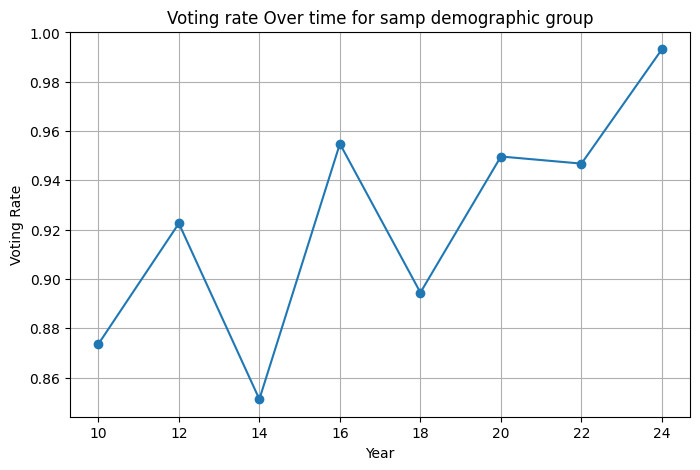

In [40]:
import matplotlib.pyplot as plt
# this is a test of the group id 
# looking at demographic group region 1, masters and above, 55-64 years old, high income

plt.figure(figsize=(8,5))
plt.plot(group_ts["year"], group_ts["did_vote_1"], marker="o")
plt.title("Voting rate Over time for samp demographic group")
plt.xlabel("Year")
plt.ylabel("Voting Rate")
plt.grid(True)
plt.show()

In [45]:
# tracking the group ids over time to see if they are consistent
group_counts = data.groupby("group_id").size().reset_index(name='count')
# sorting by count to see which groups are most common
group_counts = group_counts.sort_values(by='count', ascending=False)
#print(group_counts.head(50))

# group survival rate (we have a group id that persists over all 7 years)
group_survival = (
    data.groupby("group_id")["year"]
    .nunique()
    .reset_index(name='year_count')
)
# percentage of groups that survive all 7 years
num_full_groups = (group_survival["year_count"] == 8).sum()
total_groups = len(group_survival)

percentage = num_full_groups / total_groups

print(percentage)

1.0


In [42]:
# why is there such a high count of groups that only appear in one year??
one_year_groups = group_survival[group_survival["year_count"] == 1]["group_id"]
one_year_data = data[data["group_id"].isin(one_year_groups)]
year_counts = one_year_data["year"].value_counts().sort_index()
print(year_counts)

Series([], Name: count, dtype: int64)


In [43]:
# problematic year is 2014 
df_14 = data[data["year"] == 14]
df_12 = data[data["year"] == 12]
set(df_14["education_grouped"]) - set(df_12["education_grouped"])
cols = ["education_grouped", "age_group", "family_income_grouped", "geo_region"]

for col in cols:
    diff = set(df_14[col]) - set(df_12[col])
    print(f"{col}: {diff}")

education_grouped: set()
age_group: set()
family_income_grouped: set()
geo_region: set()


In [6]:
#df_14["geo_region"].value_counts()
# soemthing super weird going on in 2014 with the regions 

# reading in the 2014 data to see if there is just an issue in the aggregation 
raw_14 = pd.read_csv("clean_data/years/nov14pub_clean.csv")
# value counts of the geo region in the raw data
print(raw_14["GEDIV"].value_counts())

# all of the regions in 2014 are 0, so either need to remove geographic region from the grouping or use states, or skip 2014 entirely

GEDIV
0    80292
Name: count, dtype: int64


In [7]:
# maybe the variable is renamed to something different in that year?
# or we are going to have to impute from the state level data 
raw_10 = pd.read_csv("clean_data/years/nov10pub_clean.csv")
print(raw_10["GEDIV"].value_counts())

GEDIV
5    13749
9    10438
4     9976
3     9451
1     9232
8     7963
2     7177
7     6365
6     4134
Name: count, dtype: int64


In [8]:
# can we just impute the state variable
print(raw_14["GESTFIPS"].value_counts())

GESTFIPS
6     5913
48    3848
12    3059
36    2975
42    2392
39    2301
17    2203
26    1822
37    1763
22    1749
13    1716
51    1646
54    1621
28    1523
47    1502
1     1498
34    1477
33    1474
25    1468
30    1464
24    1456
27    1416
55    1387
53    1353
5     1335
18    1321
45    1293
50    1287
8     1275
9     1271
29    1234
38    1221
21    1209
41    1203
11    1197
56    1188
15    1188
40    1170
20    1156
16    1141
35    1138
10    1089
19    1087
4     1087
49    1080
32    1079
31    1063
44    1045
23    1038
2      937
46     934
Name: count, dtype: int64


In [ ]:
# mapping the states to their abbreviations 
state_codes = {
    "AK": '02',
    "AL": "01",
    "AR": "05",
    "AZ": "04",
    "CA": "06",
    "CO": "08",
    "CT": "09",
    "DE": "10",
    "FL": "12",
    "GA": "13",
    "HI": "15",
    "IA": "19",
    "ID": "16",
    "IL": "17",
    "IN": "18",
    "KS": "20",
    "KY": "21",
    "LA": "22",
    "MA": "25",
    "MD": "24",
    "ME": "23",
    "MI": "26",
    "MN": "27",
    "MO": "29",
    "MS": "28",
    "MT": "30",
    "NC": "37",
    "ND": "38",
    "NE": "31",
    "NH": "33",
    "NJ": "34",
    "NM": "35",
    "NV": "32",
    "NY": "36",
    "OH": "39",
    "OK": "40",
    "OR": "41",
    "PA": "42",
    "RI": "44",
    "SC": "45",
    "SD": "46",
    "TN": "47",
    "TX": "48",
    "UT": "49",
    "VA": "51",
    "VT": "50",
    "WA": "53",
    "WI": "55",
    "WV": "54",
    "WY": "56"
}

state_fips_rev = {v: k for k, v in state_codes.items()}

raw_14["state_coded"] = raw_14["GESTFIPS"].astype(str).str.zfill(2)

raw_14["states_encoded"] = raw_14["state_coded"].map(state_fips_rev)

{'02': 'AK', '01': 'AL', '05': 'AR', '04': 'AZ', '06': 'CA', '08': 'CO', '09': 'CT', '10': 'DE', '12': 'FL', '13': 'GA', '15': 'HI', '19': 'IA', '16': 'ID', '17': 'IL', '18': 'IN', '20': 'KS', '21': 'KY', '22': 'LA', '25': 'MA', '24': 'MD', '23': 'ME', '26': 'MI', '27': 'MN', '29': 'MO', '28': 'MS', '30': 'MT', '37': 'NC', '38': 'ND', '31': 'NE', '33': 'NH', '34': 'NJ', '35': 'NM', '32': 'NV', '36': 'NY', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', '44': 'RI', '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT', '51': 'VA', '50': 'VT', '53': 'WA', '55': 'WI', '54': 'WV', '56': 'WY'}


In [22]:
print(raw_14["states_encoded"].value_counts())

states_encoded
CA    5913
TX    3848
FL    3059
NY    2975
PA    2392
OH    2301
IL    2203
MI    1822
NC    1763
LA    1749
GA    1716
VA    1646
WV    1621
MS    1523
TN    1502
AL    1498
NJ    1477
NH    1474
MA    1468
MT    1464
MD    1456
MN    1416
WI    1387
WA    1353
AR    1335
IN    1321
SC    1293
VT    1287
CO    1275
CT    1271
MO    1234
ND    1221
KY    1209
OR    1203
WY    1188
HI    1188
OK    1170
KS    1156
ID    1141
NM    1138
DE    1089
IA    1087
AZ    1087
UT    1080
NV    1079
NE    1063
RI    1045
ME    1038
AK     937
SD     934
Name: count, dtype: int64


In [27]:
# mapping the states to the regions 
state_region = {
    # 1: New England
    "CT": 1, "ME": 1, "MA": 1, "NH": 1, "RI": 1, "VT": 1,

    # 2: Middle Atlantic
    "NJ": 2, "NY": 2, "PA": 2,

    # 3: East North Central
    "IL": 3, "IN": 3, "MI": 3, "OH": 3, "WI": 3,

    # 4: West North Central
    "IA": 4, "KS": 4, "MN": 4, "MO": 4, "NE": 4, "ND": 4, "SD": 4,

    # 5: South Atlantic
    "DE": 5, "FL": 5, "GA": 5, "MD": 5, "NC": 5, "SC": 5, "VA": 5, "WV": 5,

    # 6: East South Central
    "AL": 6, "KY": 6, "MS": 6, "TN": 6,

    # 7: West South Central
    "AR": 7, "LA": 7, "OK": 7, "TX": 7,

    # 8: Mountain
    "AZ": 8, "CO": 8, "ID": 8, "MT": 8, "NV": 8, "NM": 8, "UT": 8, "WY": 8,

    # 9: Pacific
    "AK": 9, "CA": 9, "HI": 9, "OR": 9, "WA": 9
}

raw_14["geo_region_imputed"] = raw_14["states_encoded"].map(state_region)

#print(raw_14["geo_region_imputed"].value_counts())
# remove the decimals from the region variable

raw_14["geo_region_imputed"] = raw_14["geo_region_imputed"].astype("Int64")
print(raw_14["geo_region_imputed"].value_counts())

geo_region_imputed
5    13643
9    10594
8     9452
3     9034
4     8111
7     8102
1     7583
2     6844
6     5732
Name: count, dtype: Int64
